In [ ]:
import os

dataset_path= '/content/drive/My Drive/DATASET'

if os.path.exists(dataset_path):
  print(f"Found dataset folder at {dataset_path}")
  print("Files inside:")
  print(os.listdir(dataset_path))
else:
  print("Dataset folder not found! Check the path.")

Dataset folder not found! Check the path.


In [ ]:
train_path = os.path.join(dataset_path, 'TRAIN')
print("Train folder contents:", os.listdir(train_path))

test_path = os.path.join(dataset_path, 'TEST')
print("Test folder contents:", os.listdir(test_path))


In [ ]:
import os

def list_images(base_path):
    images = []
    # Walk through all subfolders (O, R) and files
    for root, dirs, files in os.walk(base_path):
        for file in files:
            # Optional: filter for image files only (jpg, png, etc.)
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                images.append(os.path.join(root, file))
    return images

# Paths to train O and R folders
train_o_path = '/content/drive/My Drive/dataset/train/O'
train_r_path = '/content/drive/My Drive/dataset/train/R'

train_o_images = list_images(train_o_path)
train_r_images = list_images(train_r_path)

test_o_path = '/content/drive/My Drive/dataset/test/O'
test_r_path = '/content/drive/My Drive/dataset/test/R'

test_o_images = list_images(test_o_path)
test_r_images = list_images(test_r_path)

print(f"Test O images count: {len(test_o_images)}")
print(f"Test R images count: {len(test_r_images)}")


print(f"Train O images count: {len(train_o_images)}")
print(f"Train R images count: {len(train_r_images)}")

# Example: print first 5 image paths from each
print("Sample O images:", train_o_images[:5])
print("Sample R images:", train_r_images[:5])

print("Sample O images:", test_o_images[:5])
print("Sample R images:", test_r_images[:5])


In [ ]:
import os
import shutil
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import urllib.request
from zipfile import ZipFile

# Make sure your runtime has GPU enabled for faster training:
# Runtime > Change runtime type > Hardware accelerator > GPU


In [ ]:
dataset_url = 'https://github.com/abhi4ssj/smart-trash-bin-dataset/archive/refs/heads/main.zip'
dataset_path = 'dataset.zip'

# Download the dataset zip file
urllib.request.urlretrieve(dataset_url, dataset_path)

# Extract the dataset
with ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall()

# Rename extracted folder for convenience
os.rename('smart-trash-bin-dataset-main', 'dataset')

print("Dataset downloaded and extracted!")


In [ ]:
# Step 1: Install TensorFlow Datasets (if needed)
!pip install tensorflow-datasets

# Step 2: Import Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Step 3: Load 'trash' dataset from TFDS
# It has classes like 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'
(ds_train, ds_val), ds_info = tfds.load(
    'trash',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,  # returns (image, label) pairs
    with_info=True
)

# Step 4: Define class names
class_names = ds_info.features['label'].names
print("Classes:", class_names)

# Step 5: Preprocessing functions
IMG_SIZE = 128

def format_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # normalize to [0,1]
    return image, label

ds_train = ds_train.map(format_image).batch(32).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(format_image).batch(32).prefetch(tf.data.AUTOTUNE)

# Step 6: Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Step 7: Train the model
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10
)

# Step 8: Plot training history
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()


In [ ]:
!pip install opencv-python-headless tensorflow


In [ ]:
# Install necessary packages
!pip install opencv-python-headless tensorflow

import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import shutil

# Set up folder structure
base_dir = 'synthetic_trash_dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

classes = ['O', 'R']

def create_dirs():
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    for folder in [train_dir, test_dir]:
        for c in classes:
            os.makedirs(os.path.join(folder, c))

create_dirs()

IMG_SIZE = 64

def generate_circle_image():
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    center = (IMG_SIZE//2, IMG_SIZE//2)
    radius = IMG_SIZE//3
    color = (255, 255, 255)
    thickness = -1
    cv2.circle(img, center, radius, color, thickness)
    return img

def generate_rectangle_image():
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    start_point = (IMG_SIZE//4, IMG_SIZE//4)
    end_point = (3*IMG_SIZE//4, 3*IMG_SIZE//4)
    color = (255, 255, 255)
    thickness = -1
    cv2.rectangle(img, start_point, end_point, color, thickness)
    return img

def augment_image(img):
    noise = np.random.randint(0, 50, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    img = cv2.add(img, noise)
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((IMG_SIZE/2, IMG_SIZE/2), angle, 1)
    img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
    return img

def generate_and_save_images(num_images, folder):
    for i in range(num_images//2):
        img_o = generate_circle_image()
        img_o = augment_image(img_o)
        cv2.imwrite(os.path.join(folder, 'O', f'O_{i}.png'), img_o)

        img_r = generate_rectangle_image()
        img_r = augment_image(img_r)
        cv2.imwrite(os.path.join(folder, 'R', f'R_{i}.png'), img_r)

print("Generating training images...")
generate_and_save_images(20000, train_dir)

print("Generating testing images...")
generate_and_save_images(5000, test_dir)

print("Dataset created!")

IMG_HEIGHT, IMG_WIDTH = IMG_SIZE, IMG_SIZE
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print(model.summary())

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

model.save('synthetic_trash_classifier.h5')
print("Model training complete and saved as synthetic_trash_classifier.h5")


In [ ]:
# Install necessary packages
!pip install opencv-python-headless tensorflow

import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import shutil

# Set up folder structure
base_dir = 'synthetic_trash_dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

classes = ['O', 'R']

def create_dirs():
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    for folder in [train_dir, test_dir]:
        for c in classes:
            os.makedirs(os.path.join(folder, c))

create_dirs()

IMG_SIZE = 64

def generate_circle_image():
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    center = (IMG_SIZE//2, IMG_SIZE//2)
    radius = IMG_SIZE//3
    color = (255, 255, 255)
    thickness = -1
    cv2.circle(img, center, radius, color, thickness)
    return img

def generate_rectangle_image():
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    start_point = (IMG_SIZE//4, IMG_SIZE//4)
    end_point = (3*IMG_SIZE//4, 3*IMG_SIZE//4)
    color = (255, 255, 255)
    thickness = -1
    cv2.rectangle(img, start_point, end_point, color, thickness)
    return img

def augment_image(img):
    noise = np.random.randint(0, 50, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    img = cv2.add(img, noise)
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((IMG_SIZE/2, IMG_SIZE/2), angle, 1)
    img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
    return img

def generate_and_save_images(num_images, folder):
    for i in range(num_images//2):
        img_o = generate_circle_image()
        img_o = augment_image(img_o)
        cv2.imwrite(os.path.join(folder, 'O', f'O_{i}.png'), img_o)

        img_r = generate_rectangle_image()
        img_r = augment_image(img_r)
        cv2.imwrite(os.path.join(folder, 'R', f'R_{i}.png'), img_r)

print("Generating training images...")
generate_and_save_images(20000, train_dir)

print("Generating testing images...")
generate_and_save_images(5000, test_dir)

print("Dataset created!")

IMG_HEIGHT, IMG_WIDTH = IMG_SIZE, IMG_SIZE
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print(model.summary())

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

model.save('synthetic_trash_classifier.keras')
print("Model training complete and saved as synthetic_trash_classifier.keras")


In [ ]:
import os
import numpy as np
from PIL import Image, ImageDraw
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base config
img_size = (64, 64)
num_images = 25000
train_split = 0.8
base_path = "/mnt/data/smart_trash_dataset"
classes = ['O', 'R']

# Make directories
for subset in ['train', 'test']:
    for label in classes:
        os.makedirs(os.path.join(base_path, subset, label), exist_ok=True)

def create_synthetic_image(label):
    img = Image.new('RGB', img_size, color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    if label == 'O':
        for _ in range(2):
            shape = random.choice(['banana', 'leaf', 'apple', 'corn', 'bread'])
            if shape == 'banana':
                draw.ellipse([10, 20, 40, 40], fill=(255, 255, 102))  # Yellow
            elif shape == 'leaf':
                draw.polygon([(32, 15), (40, 32), (32, 50), (24, 32)], fill=(0, 180, 0))  # Green
            elif shape == 'apple':
                draw.ellipse([20, 20, 44, 44], fill=(255, 0, 0))  # Red
            elif shape == 'corn':
                draw.ellipse([25, 10, 40, 50], fill=(255, 204, 0))  # Yellow
                for i in range(12):
                    x = random.randint(28, 37)
                    y = random.randint(15, 45)
                    draw.rectangle([x, y, x+1, y+1], fill=(255, 255, 255))
            elif shape == 'bread':
                draw.rounded_rectangle([20, 25, 44, 45], radius=5, fill=(210, 180, 140))  # Brown

    else:
        for _ in range(2):
            shape = random.choice(['box', 'bottle', 'can', 'paper', 'detergent'])
            if shape == 'box':
                draw.rectangle([15, 20, 45, 40], fill=(150, 75, 0))  # Brown cardboard
            elif shape == 'bottle':
                draw.rectangle([28, 15, 36, 45], fill=(0, 191, 255))  # Blue
                draw.ellipse([28, 10, 36, 16], fill=(0, 191, 255))
            elif shape == 'can':
                draw.ellipse([25, 15, 40, 45], fill=(192, 192, 192))  # Silver/gray
            elif shape == 'paper':
                draw.rectangle([20, 25, 44, 40], fill=(220, 220, 220))  # Light gray
            elif shape == 'detergent':
                draw.polygon([(30, 15), (40, 20), (38, 45), (25, 45), (22, 30)], fill=(255, 0, 255))  # Pink

    return img


# Generate and save images
for i in range(num_images):
    subset = 'train' if i < num_images * train_split else 'test'
    label = random.choice(classes)
    img = create_synthetic_image(label)
    img.save(os.path.join(base_path, subset, label, f"{label}_{i}.png"))


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Image generators
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

datagen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary'
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary'
)

# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(train_gen, epochs=10, validation_data=test_gen)

# Save model
model.save("smart_trash_bin_model.keras")


In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Base path and image size
base_path = "/mnt/data/smart_trash_dataset"  # <-- update with your actual path
img_size = (64, 64)

# Image generators
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

datagen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary'
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary'
)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))

# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model with class weights
model.fit(train_gen, epochs=10, validation_data=test_gen, class_weight=class_weights)

# Save model
model.save("smart_trash_bin_model.keras")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("smart_trash_bin_model.keras")


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- Config ---
model_path = "smart_trash_bin_model.keras"
test_dir = "/mnt/data/smart_trash_dataset/test"
img_size = (64, 64)
batch_size = 32

# --- Load the trained model ---
model = tf.keras.models.load_model(model_path)

# --- Prepare test data ---
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Important for correct label mapping
)

# --- Predict ---
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# --- True labels ---
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- Evaluation Report ---
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))


In [ ]:
import matplotlib.pyplot as plt

# Display some images with predictions
x_test, _ = next(test_generator)  # Grab one batch
for i in range(5):
    plt.imshow(x_test[i])
    pred = "O" if predicted_classes[i] == 0 else "R"
    true = "O" if true_classes[i] == 0 else "R"
    plt.title(f"Predicted: {pred}, Actual: {true}")
    plt.axis('off')
    plt.show()


In [ ]:
print("Class indices:", test_generator.class_indices)
print("Test class counts:", np.bincount(test_generator.classes))



In [ ]:
# Install xxd if not available (for converting TFLite model to C array)
!apt-get update
!apt-get install xxd

# Check TensorFlow version and upgrade if needed
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
# Uncomment the following line if you need to upgrade TensorFlow
# !pip install --upgrade tensorflow

import numpy as np
from PIL import Image, ImageDraw
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import random
from google.colab import files

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Function to create a random background with clutter
def create_cluttered_background(size=(64, 64)):
    img = Image.new("RGB", size, color=(random.randint(100, 200), random.randint(100, 200), random.randint(100, 200)))
    draw = ImageDraw.Draw(img)
    for _ in range(random.randint(3, 8)):
        x, y = random.randint(0, size[0]), random.randint(0, size[1])
        r = random.randint(2, 5)
        draw.ellipse([x-r, y-r, x+r, y+r], fill=tuple(np.random.randint(50, 150, 3)))
    return img

# Function to add simulated lighting (shadow/highlight)
def add_lighting_effect(img):
    img_array = np.array(img)
    center_x, center_y = img_array.shape[0] // 2, img_array.shape[1] // 2
    for x in range(img_array.shape[0]):
        for y in range(img_array.shape[1]):
            distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
            factor = 1 - (distance / (img_array.shape[0] * 0.7))
            factor = max(0.5, factor)
            img_array[x, y] = np.clip(img_array[x, y] * factor, 0, 255)
    return Image.fromarray(img_array.astype(np.uint8))

# Function to create synthetic images representing garbage
def create_synthetic_image(label, size=(64, 64)):
    img = create_cluttered_background(size)
    draw = ImageDraw.Draw(img)

    center_x, center_y = size[0] // 2, size[1] // 2
    radius = np.random.randint(8, 18)
    color1 = tuple(np.random.randint(0, 256, 3))
    color2 = tuple(np.random.randint(0, 256, 3))
    rotation = np.random.randint(0, 360)

    img = img.rotate(rotation, resample=Image.BICUBIC, fillcolor="gray")
    draw = ImageDraw.Draw(img)

    if label == 0:  # Class "O" - Organic (irregular, natural shapes)
        shape_type = np.random.choice(["banana_peel", "leaf", "food_waste"])
        if shape_type == "banana_peel":
            points = [(center_x + np.random.randint(-radius, radius),
                       center_y + np.random.randint(-radius, radius)) for _ in range(8)]
            draw.polygon(points, fill=(255, 255, 0), outline=(139, 69, 19))
            for _ in range(5):
                x, y = center_x + np.random.randint(-radius//2, radius//2), center_y + np.random.randint(-radius//2, radius//2)
                draw.ellipse([x-2, y-2, x+2, y+2], fill=(139, 69, 19))
        elif shape_type == "leaf":
            draw.ellipse([center_x - radius, center_y - radius * 1.5,
                          center_x + radius, center_y + radius * 1.5],
                         fill=(34, 139, 34), outline=(0, 100, 0))
            for a in range(0, 360, 30):
                x = center_x + radius * np.cos(np.radians(a)) + np.random.randint(-3, 3)
                y = center_y + radius * 1.5 * np.sin(np.radians(a)) + np.random.randint(-3, 3)
                draw.line((center_x, center_y, x, y), fill=(0, 100, 0), width=1)
        elif shape_type == "food_waste":
            points = [(center_x + radius * np.cos(np.radians(a)) + np.random.randint(-8, 8),
                       center_y + radius * np.sin(np.radians(a)) + np.random.randint(-8, 8))
                      for a in range(0, 360, 45)]
            draw.polygon(points, fill=(165, 42, 42), outline=(0, 0, 0))
            for _ in range(3):
                x, y = center_x + np.random.randint(-radius//2, radius//2), center_y + np.random.randint(-radius//2, radius//2)
                draw.line((x-5, y, x+5, y), fill=(0, 0, 0), width=1)

    else:  # Class "R" - Recyclable (structured shapes)
        shape_type = np.random.choice(["bottle", "can", "box"])
        if shape_type == "bottle":
            draw.rectangle([center_x - radius // 2, center_y - radius,
                            center_x + radius // 2, center_y + radius],
                           fill=(169, 169, 169), outline=(0, 0, 0))
            draw.rectangle([center_x - radius // 4, center_y - radius * 1.5,
                            center_x + radius // 4, center_y - radius],
                           fill=(169, 169, 169), outline=(0, 0, 0))
            draw.rectangle([center_x - radius // 3, center_y - radius // 2,
                            center_x + radius // 3, center_y + radius // 2],
                           fill=(255, 255, 255), outline=(0, 0, 0))
        elif shape_type == "can":
            draw.ellipse([center_x - radius, center_y - radius * 1.2,
                          center_x + radius, center_y + radius * 1.2],
                         fill=(192, 192, 192), outline=(0, 0, 0))
            for y in range(center_y - radius, center_y + radius, 5):
                draw.line((center_x - radius, y, center_x + radius, y), fill=(150, 150, 150), width=1)
        elif shape_type == "box":
            draw.rectangle([center_x - radius, center_y - radius,
                            center_x + radius, center_y + radius],
                           fill=(165, 42, 42), outline=(0, 0, 0))
            draw.line((center_x - radius, center_y, center_x + radius, center_y), fill=(200, 200, 200), width=2)

    # Add lighting effect
    img = add_lighting_effect(img)
    draw = ImageDraw.Draw(img)

    # Add speckles (random small dots)
    for _ in range(np.random.randint(5, 15)):
        x, y = np.random.randint(0, size[0]), np.random.randint(0, size[1])
        draw.ellipse([x-2, y-2, x+2, y+2], fill=tuple(np.random.randint(0, 256, 3)))

    # Add noise to the image
    img_array = np.array(img)
    noise = np.random.normal(0, 20, img_array.shape).astype(np.uint8)
    img_array = np.clip(img_array + noise, 0, 255)

    return img_array / 255.0

# Generate synthetic dataset (balanced classes)
num_samples_per_class = 7500  # Total: 15000 samples
data = []
labels = []

# Class "O"
for _ in range(num_samples_per_class):
    img = create_synthetic_image(label=0)
    data.append(img)
    labels.append(0)

# Class "R"
for _ in range(num_samples_per_class):
    img = create_synthetic_image(label=1)
    data.append(img)
    labels.append(1)

data = np.array(data)
labels = np.array(labels)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Data augmentation to prevent overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

# Build the CNN model
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3),
                  kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=15, batch_size=64,
                    validation_split=0.2, verbose=1)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Predict on test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted_classes, target_names=["O", "R"]))

# Visualize some predictions (display inline and download)
for i in range(5):
    plt.imshow(X_test[i])
    pred = "O" if predicted_classes[i] == 0 else "R"
    true = "O" if y_test[i] == 0 else "R"
    plt.title(f"Predicted: {pred}, Actual: {true}")
    plt.axis('off')
    plt.savefig(f'prediction_{i}.png')
    plt.show()
    files.download(f'prediction_{i}.png')

# Convert the model to TensorFlow Lite for Microcontrollers (TFLM)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite model
with open('garbage_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

# Convert the TFLite model to a C array for ESP32
!xxd -i garbage_classifier.tflite > model_data.h

# Download the model_data.h file for ESP32 deployment
files.download('garbage_classifier.tflite')
files.download('model_data.h')

print("Model saved as garbage_classifier.tflite and converted to model_data.h for ESP32 deployment.")

In [ ]:

!apt-get update
!apt-get install xxd


import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import numpy as np
from PIL import Image, ImageDraw
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import random
from google.colab import files


np.random.seed(42)
tf.random.set_seed(42)


def create_realistic_background(size=(64, 64)):
    img = Image.new("RGB", size, color=(150, 150, 150))
    draw = ImageDraw.Draw(img)
    for y in range(0, size[1], 5):
        draw.line((0, y, size[0], y), fill=(130 + random.randint(-10, 10), 130 + random.randint(-10, 10), 130 + random.randint(-10, 10)), width=1)
    for _ in range(random.randint(5, 10)):
        x, y = random.randint(0, size[0]), random.randint(0, size[1])
        r = random.randint(1, 3)
        draw.ellipse([x-r, y-r, x+r, y+r], fill=(100, 100, 100))
    return img


def add_lighting_effect(img):
    img_array = np.array(img)
    center_x, center_y = img_array.shape[0] // 2, img_array.shape[1] // 2
    light_x, light_y = random.randint(0, img_array.shape[0]), random.randint(0, img_array.shape[1])
    for x in range(img_array.shape[0]):
        for y in range(img_array.shape[1]):
            distance = np.sqrt((x - light_x)**2 + (y - light_y)**2)
            factor = 1 - (distance / (img_array.shape[0] * 1.0))
            factor = max(0.4, min(1.2, factor))
            img_array[x, y] = np.clip(img_array[x, y] * factor, 0, 255)
    return Image.fromarray(img_array.astype(np.uint8))


def create_synthetic_image(label, size=(64, 64)):
    img = create_realistic_background(size)
    draw = ImageDraw.Draw(img)

    center_x, center_y = size[0] // 2, size[1] // 2
    radius = np.random.randint(8, 18)
    rotation = np.random.randint(0, 360)

    img = img.rotate(rotation, resample=Image.BICUBIC, fillcolor="gray")
    draw = ImageDraw.Draw(img)

    if label == 0:
        shape_type = np.random.choice(["banana_peel", "leaf", "fruit_piece"])
        if shape_type == "banana_peel":
            points = [(center_x + np.random.randint(-radius, radius),
                       center_y + np.random.randint(-radius, radius)) for _ in range(10)]
            draw.polygon(points, fill=(255, 255, 0), outline=(139, 69, 19))
            for _ in range(8):
                x, y = center_x + np.random.randint(-radius//2, radius//2), center_y + np.random.randint(-radius//2, radius//2)
                draw.ellipse([x-2, y-2, x+2, y+2], fill=(139, 69, 19))
                draw.line((x-5, y, x+5, y), fill=(139, 69, 19), width=1)
        elif shape_type == "leaf":
            draw.ellipse([center_x - radius, center_y - radius * 1.5,
                          center_x + radius, center_y + radius * 1.5],
                         fill=(34, 139, 34), outline=(0, 100, 0))
            for a in range(0, 360, 20):
                x = center_x + radius * np.cos(np.radians(a)) + np.random.randint(-5, 5)
                y = center_y + radius * 1.5 * np.sin(np.radians(a)) + np.random.randint(-5, 5)
                draw.line((center_x, center_y, x, y), fill=(0, 100, 0), width=1)
        elif shape_type == "fruit_piece":
            points = [(center_x + radius * np.cos(np.radians(a)) + np.random.randint(-10, 10),
                       center_y + radius * np.sin(np.radians(a)) + np.random.randint(-10, 10))
                      for a in range(0, 360, 30)]
            draw.polygon(points, fill=(255, 165, 0), outline=(139, 69, 19))
            for _ in range(5):
                x, y = center_x + np.random.randint(-radius//2, radius//2), center_y + np.random.randint(-radius//2, radius//2)
                draw.ellipse([x-3, y-3, x+3, y+3], fill=(255, 215, 0))

    else:
        shape_type = np.random.choice(["bottle", "crushed_can", "folded_box"])
        if shape_type == "bottle":
            draw.rectangle([center_x - radius // 2, center_y - radius,
                            center_x + radius // 2, center_y + radius],
                           fill=(169, 169, 169), outline=(0, 0, 0))
            draw.rectangle([center_x - radius // 4, center_y - radius * 1.5,
                            center_x + radius // 4, center_y - radius],
                           fill=(169, 169, 169), outline=(0, 0, 0))
            draw.rectangle([center_x - radius // 3, center_y - radius // 2,
                            center_x + radius // 3, center_y + radius // 2],
                           fill=(255, 255, 255), outline=(0, 0, 0))
            draw.line((center_x - radius // 2, center_y - radius,
                       center_x + radius // 2, center_y - radius),
                      fill=(200, 200, 200), width=2)
        elif shape_type == "crushed_can":
            points = [(center_x + radius * np.cos(np.radians(a)) + np.random.randint(-5, 5),
                       center_y + radius * 1.2 * np.sin(np.radians(a)) + np.random.randint(-5, 5))
                      for a in range(0, 360, 30)]
            draw.polygon(points, fill=(192, 192, 192), outline=(0, 0, 0))
            for y in range(center_y - radius, center_y + radius, 5):
                draw.line((center_x - radius, y, center_x + radius, y), fill=(150, 150, 150), width=1)
        elif shape_type == "folded_box":
            points = [(center_x - radius + np.random.randint(-5, 5), center_y - radius + np.random.randint(-5, 5)),
                      (center_x + radius + np.random.randint(-5, 5), center_y - radius + np.random.randint(-5, 5)),
                      (center_x + radius + np.random.randint(-5, 5), center_y + radius + np.random.randint(-5, 5)),
                      (center_x - radius + np.random.randint(-5, 5), center_y + radius + np.random.randint(-5, 5))]
            draw.polygon(points, fill=(165, 42, 42), outline=(0, 0, 0))
            draw.line((center_x - radius, center_y, center_x + radius, center_y), fill=(200, 200, 200), width=2)


    img = add_lighting_effect(img)
    draw = ImageDraw.Draw(img)


    for _ in range(np.random.randint(5, 15)):
        x, y = np.random.randint(0, size[0]), np.random.randint(0, size[1])
        draw.ellipse([x-2, y-2, x+2, y+2], fill=tuple(np.random.randint(0, 256, 3)))


    img_array = np.array(img)
    noise = np.random.normal(0, 25, img_array.shape).astype(np.uint8)
    img_array = np.clip(img_array + noise, 0, 255)

    return img_array / 255.0


num_samples_per_class = 7500
data = []
labels = []


for _ in range(num_samples_per_class):
    img = create_synthetic_image(label=0)
    data.append(img)
    labels.append(0)

for _ in range(num_samples_per_class):
    img = create_synthetic_image(label=1)
    data.append(img)
    labels.append(1)

data = np.array(data)
labels = np.array(labels)


X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])


model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    data_augmentation,
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=30, batch_size=64,
                    validation_split=0.2, verbose=1)


test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")


predictions = model.predict(X_test)

predicted_classes = (predictions > 0.6).astype(int).flatten()


print("\nPrediction Scores (first 10 samples):")
for i in range(10):
    print(f"Sample {i}: Score = {predictions[i][0]:.4f}, Predicted = {'R' if predicted_classes[i] == 1 else 'O'}, Actual = {'R' if y_test[i] == 1 else 'O'}")


print("\nClassification Report:")
print(classification_report(y_test, predicted_classes, target_names=["O", "R"]))


for i in range(10):
    plt.imshow(X_test[i])
    pred = "O" if predicted_classes[i] == 0 else "R"
    true = "O" if y_test[i] == 0 else "R"
    plt.title(f"Predicted: {pred}, Actual: {true}, Score: {predictions[i][0]:.4f}")
    plt.axis('off')
    plt.savefig(f'prediction_{i}.png')
    plt.show()
    files.download(f'prediction_{i}.png')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('garbage_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

!xxd -i garbage_classifier.tflite > model_data.h

files.download('garbage_classifier.tflite')
files.download('model_data.h')

print("Model saved as garbage_classifier.tflite and converted to model_data.h for ESP32 deployment.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = '/content/drive/MyDrive/DATASET'

train_dir = os.path.join(base_dir, 'TRAIN')
test_dir = os.path.join(base_dir, 'TEST')

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2,
                                   shear_range=0.2, zoom_range=0.2, horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

# train_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=img_size,
#     batch_size=batch_size,
#     class_mode='binary'
# )

# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=img_size,
#     batch_size=batch_size,
#     class_mode='binary'
# )
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/DATASET/TRAIN',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    subset='training'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/DATASET/TEST',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)



Found 18157 images belonging to 2 classes.
Found 1872 images belonging to 2 classes.


In [ ]:
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dropout(0.5),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


In [ ]:
model.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

# history = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=test_generator
# )

history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch=50,
    validation_steps=10,
    validation_data=test_generator
)


NameError: name 'model' is not defined

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

59/59 ━━━━━━━━━━━━━━━━━━━━ 272s 5s/step - accuracy: 0.9267 - loss: 0.2406
Test Accuracy: 83.92%


In [ ]:
model.save('garbage_classifier_model.keras')


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/garbage_classifier_model.keras')


ValueError: File not found: filepath=/content/garbage_classifier_model.keras. Please ensure the file is an accessible `.keras` zip file.

Loading: /content/drive/MyDrive/DATASET/TEST/O/O_12589.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
Prediction: Organic (O), Confidence: 0.95
Loading: /content/drive/MyDrive/DATASET/TEST/R/R_10183.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction: Recyclable (R), Confidence: 0.94
Loading: /content/drive/MyDrive/DATASET/TEST/O/O_13709.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction: Organic (O), Confidence: 0.99
Loading: /content/drive/MyDrive/DATASET/TEST/R/R_10997.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: Recyclable (R), Confidence: 0.96


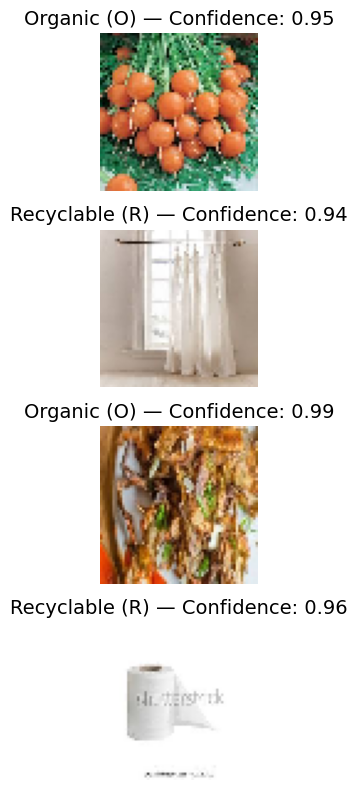

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from tensorflow.keras.preprocessing import image
# test_images = [
#     '/content/drive/MyDrive/dataset/test/O/O_12589.jpg',
#     '/content/drive/MyDrive/dataset/test/R/R_10183.jpg',
#     '/content/drive/MyDrive/dataset/test/O/O_13709.jpg',
#     '/content/drive/MyDrive/dataset/test/R/R_10997.jpg',
# ]
# def predict_images(image_paths, model):
#     plt.figure(figsize=(12, len(image_paths) * 2))

#     for i, img_path in enumerate(image_paths):

#         img = image.load_img(img_path, target_size=(128, 128))
#         img_array = image.img_to_array(img) / 255.0
#         img_array = np.expand_dims(img_array, axis=0)


#         pred = model.predict(img_array)[0][0]
#         label = 'Recyclable (R)' if pred > 0.5 else 'Organic (O)'
#         confidence = pred if pred > 0.5 else 1 - pred


#         plt.subplot(len(image_paths), 1, i + 1)
#         plt.imshow(img)
#         plt.axis('off')
#         plt.title(f"{label} — Confidence: {confidence:.2f}", fontsize=14)

#     plt.tight_layout()
#     plt.show()
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

test_images = [
    '/content/drive/MyDrive/DATASET/TEST/O/O_12589.jpg',
    '/content/drive/MyDrive/DATASET/TEST/R/R_10183.jpg',
    '/content/drive/MyDrive/DATASET/TEST/O/O_13709.jpg',
    '/content/drive/MyDrive/DATASET/TEST/R/R_10997.jpg',
]

def predict_images(image_paths, model):
    plt.figure(figsize=(12, len(image_paths) * 2))

    for i, img_path in enumerate(image_paths):
        print(f"Loading: {img_path}")

        img = image.load_img(img_path, target_size=(128, 128))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)[0][0]
        label = 'Recyclable (R)' if pred > 0.5 else 'Organic (O)'
        confidence = pred if pred > 0.5 else 1 - pred

        print(f"Prediction: {label}, Confidence: {confidence:.2f}")

        plt.subplot(len(image_paths), 1, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{label} — Confidence: {confidence:.2f}", fontsize=14)

    plt.tight_layout()
    plt.show()

predict_images(test_images, model)
